In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df= pd.read_excel('online_retail_II(kaggle).xlsx')

In [3]:
print(df.sample(6))

       Invoice StockCode                        Description  Quantity  \
12247   490380     82486  WOOD S/3 CABINET ANT WHITE FINISH         4   
510411  537042    85014B             RED RETROSPOT UMBRELLA         1   
107404  499679     21935                 SUKI  SHOULDER BAG        10   
300571  518663     85152    HAND OVER THE CHOCOLATE   SIGN          1   
323291  520875     22696                WICKER WREATH LARGE         4   
499604  536027    84029E     RED WOOLLY HOTTIE WHITE HEART.        12   

               InvoiceDate  Price  Customer ID         Country  
12247  2009-12-05 13:26:00   6.95      17850.0  United Kingdom  
510411 2010-12-05 10:45:00   5.95      13838.0  United Kingdom  
107404 2010-03-02 09:11:00   1.65      13995.0  United Kingdom  
300571 2010-08-10 14:27:00   2.10      14044.0  United Kingdom  
323291 2010-08-31 15:17:00   1.95      16098.0  United Kingdom  
499604 2010-11-29 16:31:00   3.75      17090.0  United Kingdom  


In [4]:
df.shape

(525461, 8)

In [5]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.shape

(518596, 8)

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64

In [9]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [10]:
df.isnull().sum()

Invoice           0
StockCode         0
Description    2928
Quantity          0
InvoiceDate       0
Price             0
Customer ID       0
Country           0
dtype: int64

In [11]:
import pandas as pd

# =========================
# DATA PREPARATION
# =========================

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Sales column
df['Sales'] = df['Quantity'] * df['Price']

# Snapshot date (1 day after last transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# =========================
# RFM CALCULATION
# =========================

rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Sales': 'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

print(rfm.head())

             Recency  Frequency  Monetary
Customer ID                              
12346.0           67         15    -51.74
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          4   2646.99
12351.0           11          1    300.93


Shape: (518596, 9)

Missing Values
Invoice           0
StockCode         0
Description    2928
Quantity          0
InvoiceDate       0
Price             0
Customer ID       0
Country           0
Sales             0
dtype: int64

Statistics
            Quantity                    InvoiceDate          Price  \
count  518596.000000                         518596  518596.000000   
mean       10.438152  2010-06-28 06:43:01.573016320       4.716176   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%         1.000000            2010-03-21 11:07:00       1.250000   
50%         3.000000            2010-07-05 15:42:00       2.100000   
75%        10.000000            2010-10-15 11:40:00       4.210000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       108.126593                            NaN     147.090460   

         Customer ID          Sales  
count  518596.000000  518596.000000  
mean    15353.621857      18.329828  
min     12346.0

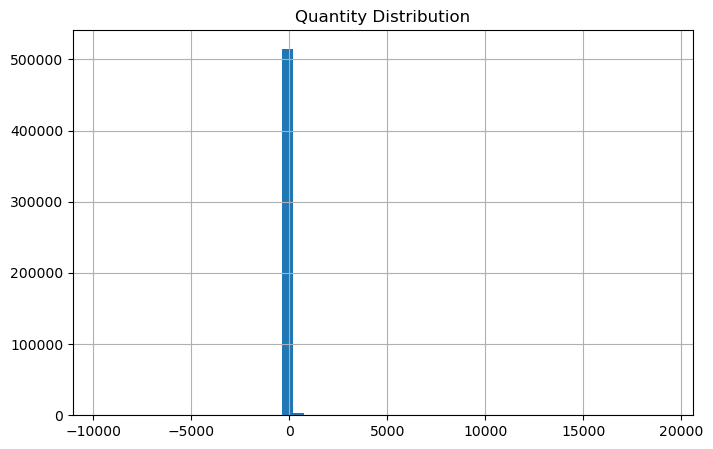

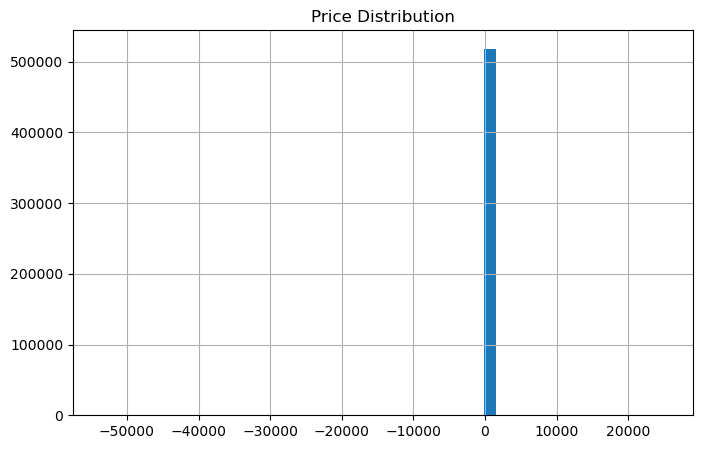

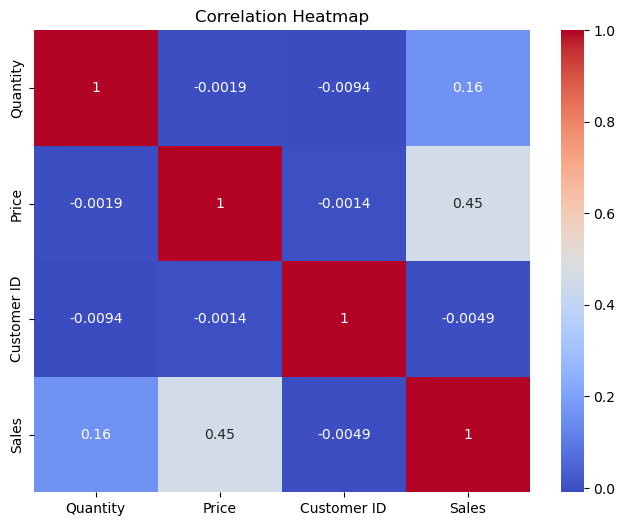


RFM Table
             Recency  Frequency  Monetary
Customer ID                              
12346.0           67         15    -51.74
12347.0            3          2   1323.32
12348.0           74          1    222.16
12349.0           43          4   2646.99
12351.0           11          1    300.93

KMeans Counts
KMeansCluster
0    2918
3     824
2     641
1       1
Name: count, dtype: int64

DBSCAN Counts
DBSCANCluster
 0    4371
-1      13
Name: count, dtype: int64


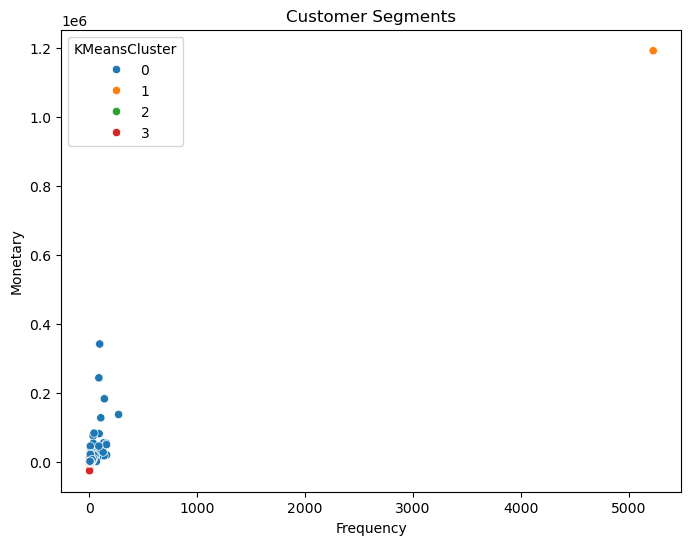


Daily Sales
          ds         y
0 2009-12-01  53010.76
1 2009-12-02  62583.66
2 2009-12-03  68027.59
3 2009-12-04  40195.80
4 2009-12-05   9803.05


In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

import mlflow

# =========================
# LOAD DATA
# =========================



print("Shape:", df.shape)

# =========================
# DATA CLEANING
# =========================

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df.drop_duplicates(inplace=True)

df.dropna(subset=['Customer ID'], inplace=True)

print("\nMissing Values")
print(df.isnull().sum())

# =========================
# EDA
# =========================

print("\nStatistics")
print(df.describe())

# Quantity Distribution

plt.figure(figsize=(8,5))
df['Quantity'].hist(bins=50)
plt.title("Quantity Distribution")
plt.show()

# Price Distribution

plt.figure(figsize=(8,5))
df['Price'].hist(bins=50)
plt.title("Price Distribution")
plt.show()

# Correlation Heatmap

numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

# =========================
# FEATURE ENGINEERING
# =========================

df['Sales'] = df['Quantity'] * df['Price']

snapshot_date = (
    df['InvoiceDate'].max()
    + pd.Timedelta(days=1)
)

# =========================
# RFM ANALYSIS
# =========================

rfm = df.groupby('Customer ID').agg({

    'InvoiceDate':
        lambda x:
        (snapshot_date - x.max()).days,

    'Invoice':
        'nunique',

    'Sales':
        'sum'
})

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

print("\nRFM Table")
print(rfm.head())

# =========================
# SCALING
# =========================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

# =========================
# KMEANS
# =========================

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['KMeansCluster'] = kmeans.fit_predict(
    rfm_scaled
)

print("\nKMeans Counts")
print(
    rfm['KMeansCluster']
    .value_counts()
)

# =========================
# DBSCAN
# =========================

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

rfm['DBSCANCluster'] = dbscan.fit_predict(
    rfm_scaled
)

print("\nDBSCAN Counts")
print(
    rfm['DBSCANCluster']
    .value_counts()
)

# =========================
# CLUSTER VISUALIZATION
# =========================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='KMeansCluster',
    palette='tab10'
)

plt.title("Customer Segments")
plt.show()

# =========================
# TIME SERIES PREPARATION
# =========================

daily_sales = (
    df.groupby(
        df['InvoiceDate'].dt.date
    )['Sales']
    .sum()
    .reset_index()
)

daily_sales.columns = [
    'ds',
    'y'
]

daily_sales['ds'] = pd.to_datetime(
    daily_sales['ds']
)

print("\nDaily Sales")
print(daily_sales.head())


In [ ]:
import prophet
print(prophet)
print(prophet.__file__)

09:25:18 - cmdstanpy - INFO - Chain [1] start processing
09:25:19 - cmdstanpy - INFO - Chain [1] done processing


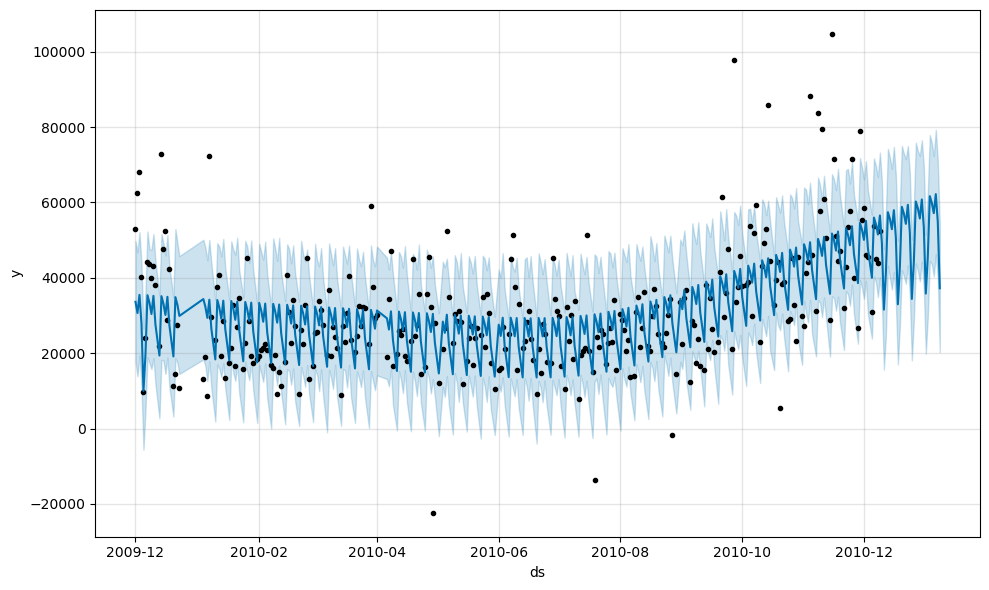

2026/06/20 09:25:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/20 09:25:25 INFO mlflow.store.db.utils: Updating database tables
2026/06/20 09:25:27 INFO mlflow.tracking.fluent: Experiment with name 'Retail_Analytics' does not exist. Creating a new experiment.



Week 1 Completed Successfully!


In [14]:
from prophet import Prophet

model = Prophet()

model.fit(daily_sales)

future = model.make_future_dataframe(
    periods=30
)

forecast = model.predict(future)

fig1 = model.plot(forecast)

plt.show()

# =========================
# SAVE OUTPUTS
# =========================

rfm.to_csv(
    "rfm_customers.csv"
)

daily_sales.to_csv(
    "daily_sales.csv",
    index=False
)

df.to_csv(
    "cleaned_retail.csv",
    index=False
)

# =========================
# MLFLOW LOGGING
# =========================

mlflow.set_experiment(
    "Retail_Analytics"
)

with mlflow.start_run():

    mlflow.log_param(
        "clusters",
        4
    )

    mlflow.log_metric(
        "customers",
        len(rfm)
    )

    mlflow.log_artifact(
        "cleaned_retail.csv"
    )

    mlflow.log_artifact(
        "rfm_customers.csv"
    )

print("\nWeek 1 Completed Successfully!")
